# **EDA**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the Data

In [2]:
ROOT_DIR = Path.cwd().parent
csv_path = ROOT_DIR / Path("data/simulated/simulated_transactions_seed_42.csv")
df = pd.read_csv(csv_path)
df.head()

,tx_id,timestamp,user_id,amount,category,device_id,auth_method,lat,lon,ip_address,is_fraud
0,e4fd6c34-d67,2026-01-19 09:59:35.248955,user_55,172.43,grocery,475287aa,PIN,-83.615968,174.348649,120.185.31.102,0
1,0cb5ee5c-62f,2026-01-18 11:55:15.356815,user_407,8.43,food,379d58f9,Biometric,20.500359,150.789724,107.109.217.82,0
2,39a0f145-a5b,2026-02-14 00:45:15.799367,user_142,1259.07,tech,bea29dfe,PIN,-87.864685,123.877867,145.56.170.82,0
3,052226b9-836,2026-01-16 11:40:03.965444,user_492,26.14,grocery,052dfb9a,Biometric,-0.992383,-52.469217,208.72.228.108,0
4,a5ba2472-21d,2026-01-26 15:56:09.026376,user_261,364.83,utilities,0d18ab95,Biometric,8.142126,36.488989,104.34.170.221,0


## Phase 1 — Target Reconnaissance

In [11]:
df.columns

Index(['tx_id', 'timestamp', 'user_id', 'amount', 'category', 'device_id',
       'auth_method', 'lat', 'lon', 'ip_address', 'is_fraud'],
      dtype='str')

In [6]:
df.is_fraud.value_counts()

is_fraud
0    9852
1     148
Name: count, dtype: int64

In [ ]:
print(f"Total number of samples: {len(df)}")
print(f"Number of fraud cases: {len(df[df['is_fraud'] == 1])}")
print(f"Percentage of fraud: {df.is_fraud.mean(): .2%}")

Total number of samples: 10000
Number of fraud cases: 148
Percentage of fraud:  1.48%


## Phase 2 — Feature Integrity Check

In [8]:
df.isna().sum().any()

np.False_

In [9]:
df.duplicated().any()

np.False_

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tx_id        10000 non-null  str    
 1   timestamp    10000 non-null  str    
 2   user_id      10000 non-null  str    
 3   amount       10000 non-null  float64
 4   category     10000 non-null  str    
 5   device_id    10000 non-null  str    
 6   auth_method  10000 non-null  str    
 7   lat          10000 non-null  float64
 8   lon          10000 non-null  float64
 9   ip_address   10000 non-null  str    
 10  is_fraud     10000 non-null  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 1.6 MB


In [ ]:
df = df.astype(
    {
        "tx_id": "object",
        "user_id": "object",
        "category": "category",
        "device_id": "object",
        "auth_method": "object",
        "ip_address": "object",
    }
)

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   tx_id        10000 non-null  object        
 1   timestamp    10000 non-null  datetime64[us]
 2   user_id      10000 non-null  object        
 3   amount       10000 non-null  float64       
 4   category     10000 non-null  category      
 5   device_id    10000 non-null  object        
 6   auth_method  10000 non-null  object        
 7   lat          10000 non-null  float64       
 8   lon          10000 non-null  float64       
 9   ip_address   10000 non-null  object        
 10  is_fraud     10000 non-null  int64         
dtypes: category(1), datetime64[us](1), float64(3), int64(1), object(5)
memory usage: 791.2+ KB


## Phase 3 — Distribution Analysis

In [ ]:
df.describe()[["amount", "lat", "lon"]]

,amount,lat,lon
count,10000.000000,10000.000000,10000.000000
mean,508.156647,-1.648046,0.186536
min,5.010000,-89.894707,-179.248190
25%,88.577500,-48.428599,-88.693927
50%,173.030000,-3.478564,-2.457356
75%,386.090000,43.773160,88.771784
max,6968.410000,89.417647,179.695685
std,853.338769,51.694022,101.659227


Boxplot for amount


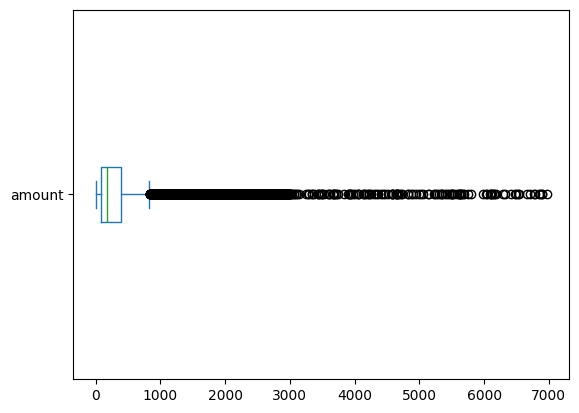

Boxplot for lat


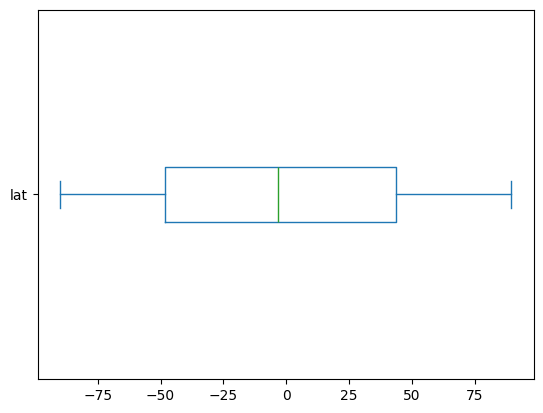

Boxplot for lon


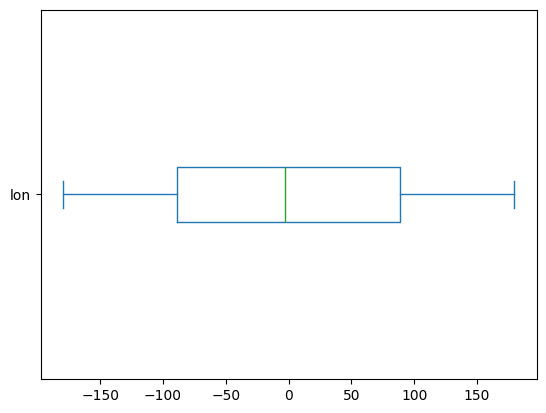

In [ ]:
df_num = df.select_dtypes(include=["float64", "int64"]).drop(columns=["is_fraud"])

for num in df_num.columns.tolist():
    print(f"Boxplot for {num}")
    plt.figure()
    df[str(num)].plot(kind="box", vert=False)
    plt.show()

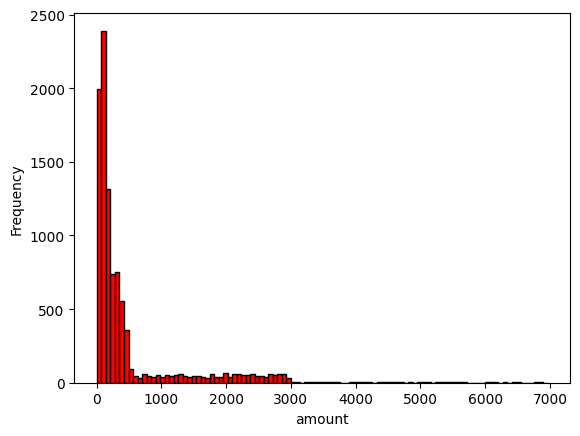

In [ ]:
df.amount.plot(kind="hist", bins=100, color="r", edgecolor="k")
plt.xlabel("amount")
plt.show()

The `amount` column has very skewness.

## Phase 4 — Fraud vs Non-Fraud Comparison

In [72]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_of_week

<Axes: title={'center': 'Count of transaction per hour of the day'}, xlabel='hour'>

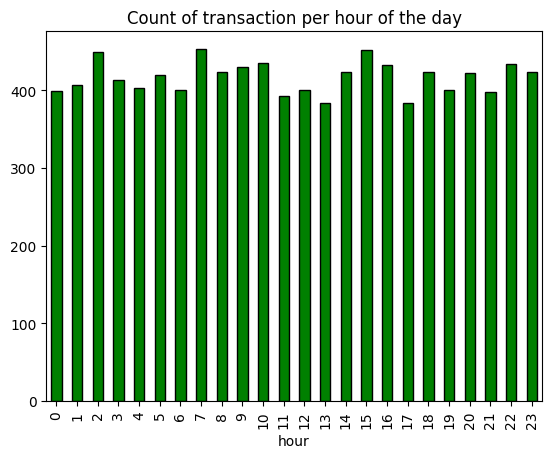

In [73]:
df.groupby(df.hour).size().plot(
    kind="bar",
    color="g",
    edgecolor="k",
    title="Count of transaction per hour of the day",
)


KeyboardInterrupt: 

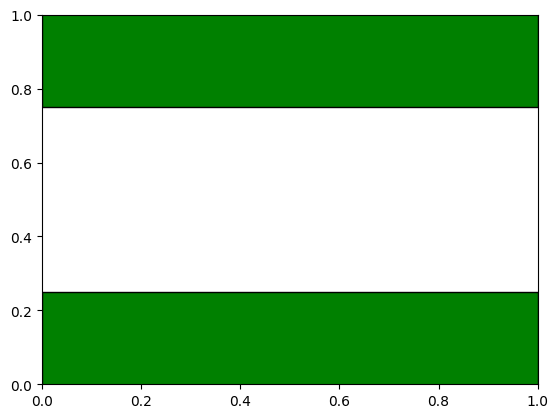

In [96]:
df.groupby(df.day_of_week).value_counts().plot(
    kind="barh",
    color="g",
    edgecolor="k",
    title="Count of transaction per day of the week",
)

In [93]:
df_f = df[df["is_fraud"] == 1]
print(f"Is there any fraud cases inside the dataframe df_f: {0 in df_f.is_fraud}")
df_f.head()

Is there any fraud cases inside the dataframe df_f: False


,tx_id,timestamp,user_id,amount,category,device_id,auth_method,lat,lon,ip_address,is_fraud,hour,day,day_of_week
91,0be7728e-6a1,2026-01-19 15:40:15.831445,user_141,4159.94,travel,a881bfd3,Password,40.712800,-74.006000,211.241.105.94,1,15,0,0
176,7463835e-eaf,2026-01-18 17:51:20.837997,user_180,3429.99,tech,3873e57f,Password,-59.430094,5.291839,209.70.230.53,1,17,6,6
238,ac777762-662,2026-01-19 14:51:23.745143,user_350,3685.53,tech,530ddda6,Password,-62.267246,-165.945136,186.241.155.14,1,14,0,0
261,29d0c613-b0c,2026-01-29 12:00:41.133895,user_331,2034.95,travel,0f79a8a7,Password,40.712800,-74.006000,80.70.72.61,1,12,3,3
393,271a919f-92a,2026-01-17 05:50:05.658144,user_399,5135.13,tech,a79313b8,Password,-54.596949,168.962329,51.254.20.68,1,5,5,5


In [95]:
df_f = df_f.set_index('timestamp')

daiy_fraud = df_f.resample('D').size()

hourly_fraud = df_f.resample('h').size()


KeyError: "None of ['timestamp'] are in the columns"

<Figure size 1200x600 with 0 Axes>

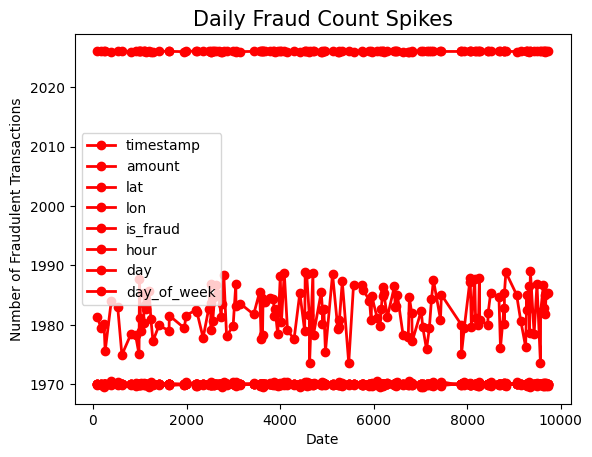

In [ ]:
plt.figure(figsize=(12, 6))
daiy_fraud.plot(kind="line", marker="o", color="red", linewidth=2)
plt.title("Daily Fraud Count Spikes", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Number of Fraudulent Transactions")
plt.show()


<Axes: title={'center': 'Count of fraud transaction per hour of the day'}, xlabel='hour'>

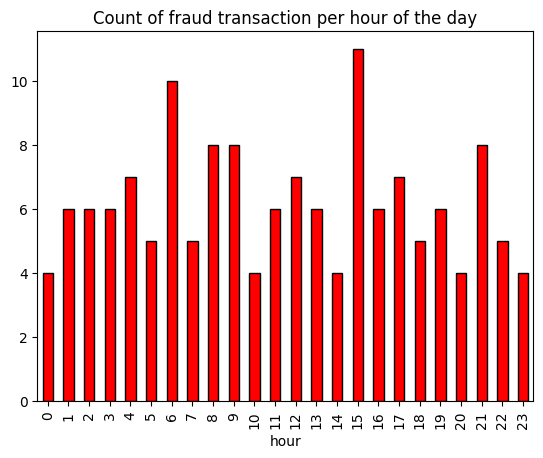

In [85]:
df_f.groupby(df_f.hour).size().plot(
    kind="bar",
    color="r",
    edgecolor="k",
    title="Count of fraud transaction per hour of the day",
)


<Axes: title={'center': 'Count of fraud transaction per day of the week'}, ylabel='day_of_week'>

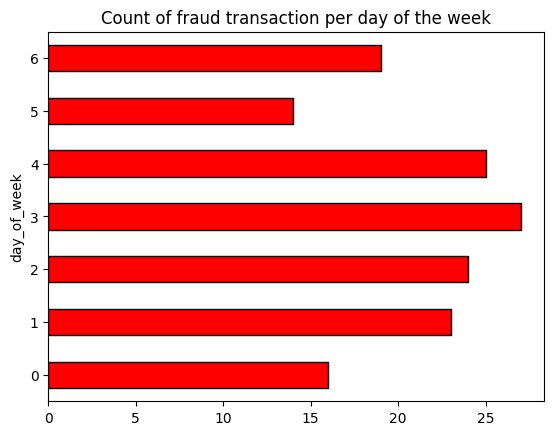

In [89]:
df_f.groupby(df.day_of_week).size().plot(
    kind="barh",
    color="r",
    edgecolor="k",
    title="Count of fraud transaction per day of the week",
)
